In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
#dataset load krwane mai help karegi
from datasets import load_dataset

d:\Deep-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [11]:
label_names = emotion_dataset['train'].features['label'].names

In [12]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [15]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [7]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

In [16]:
df_train.shape

(16000, 2)

In [17]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

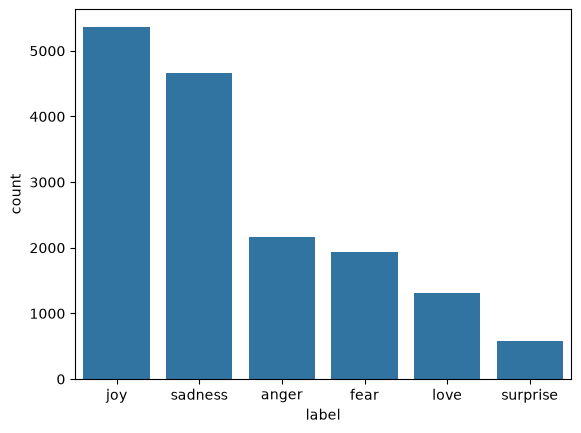

In [18]:
sns.barplot(df_train['label'].value_counts())

In [21]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


In [11]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

# rnn_model = Sequential([
#     Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
#     SimpleRNN(units=128, return_sequences=True),
#     Dropout(0.5),
#     SimpleRNN(units=64),
#     Dropout(0.5),
#     Dense(units=num_classes, activation='softmax') #Output Layer
# ])

# rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\Deep-Learning\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# rnn_model.fit(
#     padded_train_sequence,
#     train_labels,
#     validation_data=(padded_test_sequence, test_labels),
#     epochs = 20,
#     batch_size=32,
#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1602 - loss: 1.7746 - val_accuracy: 0.1380 - val_loss: 1.7915
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1666 - loss: 1.7539 - val_accuracy: 0.1445 - val_loss: 1.7820
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1626 - loss: 1.7483 - val_accuracy: 0.0885 - val_loss: 1.8418
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1807 - loss: 1.7311 - val_accuracy: 0.1360 - val_loss: 1.7870
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1863 - loss: 1.7186 - val_accuracy: 0.1005 - val_loss: 1.8399


In [ ]:
# rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
# print(f"RNN Loss: {rnn_loss}")
# print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1260 - loss: 1.7866
RNN Loss: 1.7865995168685913
RNN Accuracy: 0.12600000202655792


In [ ]:
# lstm_model = Sequential([
#     Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
#     LSTM(units=128, return_sequences=True),
#     Dropout(0.5),
#     LSTM(units=64),
#     Dropout(0.5),
#     Dense(units=num_classes, activation='softmax') #Output Layer
# ])

# lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# lstm_model.fit(
#     padded_train_sequence,
#     train_labels,
#     validation_data=(padded_test_sequence, test_labels),
#     epochs = 20,
#     batch_size=32,
#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )

# lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
# print(f"LSTM Loss: {lstm_loss}")
# print(f"LSTM Accuracy: {lstm_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8855 - loss: 0.3734
LSTM Loss: 0.37335097789764404
LSTM Accuracy: 0.8855000138282776


In [17]:
# lstm_model.save("lstm_model.keras")

In [ ]:
# lstm_model = tf.keras.models.load_model("lstm_model.keras")
# print("Model loaded and ready!")

Model loaded and ready!


In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.1501 - loss: 1.7967 - val_accuracy: 0.1375 - val_loss: 1.7927
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.1390 - loss: 1.7955 - val_accuracy: 0.0860 - val_loss: 1.7829
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.1671 - loss: 1.7940 - val_accuracy: 0.3465 - val_loss: 1.7811
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.1536 - loss: 1.7942 - val_accuracy: 0.0810 - val_loss: 1.7949
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.1603 - loss: 1.7898 - val_accuracy: 0.2840 - val_loss: 1.7723
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.1842 - loss: 1.7704 - val_accuracy: 0.1315 - val_loss: 1.7998
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.2049 - loss: 1.7363 - val_accuracy: 0.1795 - val_loss: 1.8312
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.2339 - loss: 1.6705 - 

In [ ]:
# result_df = pd.DataFrame({
#     'Model' : ['RNN', 'LSTM', 'GRU'],
#     'Test Loss': [rnn_loss, lstm_loss, gru_loss],
#     'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
#     }).sort_values(by='Test Accuracy',ascending=False)
# result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.373351,0.8855
2,GRU,1.772313,0.2840
0,RNN,1.786600,0.1260


In [28]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

d:\Deep-Learning\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 110ms/step - accuracy: 0.5984 - loss: 1.0355 - val_accuracy: 0.8865 - val_loss: 0.3677
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 92ms/step - accuracy: 0.9156 - loss: 0.2466 - val_accuracy: 0.9175 - val_loss: 0.2137
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - accuracy: 0.9442 - loss: 0.1528 - val_accuracy: 0.9155 - val_loss: 0.2350
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.9566 - loss: 0.1142 - val_accuracy: 0.9230 - val_loss: 0.2074
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 92ms/step - accuracy: 0.9712 - loss: 0.0802 - val_accuracy: 0.9300 - val_loss: 0.2108
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.9729 - loss: 0.0750 - val_accuracy: 0.9140 - val_loss: 0.2865
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - accuracy: 0.9786 - loss: 0.0618 - val_accuracy: 0.9245 - val_loss: 0.2444


In [30]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9230 - loss: 0.2074
BiGRU Loss: 0.20743635296821594
BiGRU Accuracy: 0.9229999780654907


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step


<Axes: >

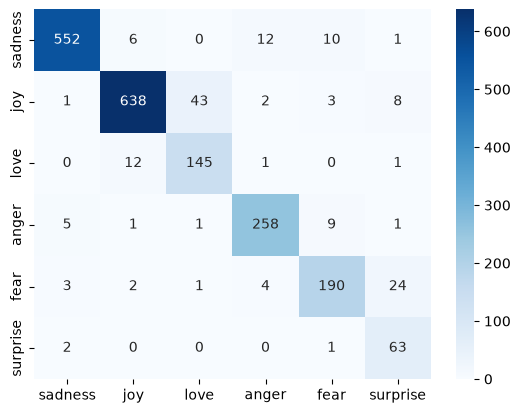

In [31]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

In [75]:
sample_texts = [
    "i am sad because i failed in exam",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Text: i am sad because i failed in exam
Predicted Emotion: fear
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [77]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)